# Import Required Libraries

In this section, we will import the necessary libraries for data analysis and visualization. These include pandas, numpy, matplotlib, seaborn, and other relevant libraries.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set(style="whitegrid")

# Load and Inspect Data

In this section, we will load the `metaData.csv` file and inspect its structure. This includes displaying the first few rows, column names, data types, and the shape of the dataset.

In [2]:
# Load and Inspect Data
# Define the file path
file_path = "../data/hackathon-recover-x-cogito/metaData.csv"

# Load the dataset
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
data.head()

,insurance_company,recover_office_zip_code,damage_address_zip_code,office_distance,case_creation_year,case_creation_month,project_id
0,C,7327.0,7327.0,"8,8",2023,11,147474
1,C,1389.0,1387.0,"4,3",2022,6,147481
2,K,8400.0,8403.0,"2,7",2020,10,147483
3,C,2150.0,2160.0,7,2023,4,147485
4,N,3262.0,3265.0,"2,5",2021,3,147486


In [3]:
# Display basic information about the dataset
print("Dataset Shape:", data.shape)
print("\nColumn Information:")
data.info()

Dataset Shape: (60010, 7)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60010 entries, 0 to 60009
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   insurance_company        60010 non-null  object 
 1   recover_office_zip_code  59870 non-null  float64
 2   damage_address_zip_code  59935 non-null  float64
 3   office_distance          60010 non-null  object 
 4   case_creation_year       60010 non-null  int64  
 5   case_creation_month      60010 non-null  int64  
 6   project_id               60010 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 3.2+ MB


## Handle Missing Values

Identify columns with missing values, show counts and percentages, and visualize the top columns by percent missing. Provide a short recommendation for handling high-missing columns.

Columns with missing values: 2


,missing_count,missing_percent
recover_office_zip_code,140,0.233294
damage_address_zip_code,75,0.124979


C:\Users\tobia\AppData\Local\Temp\ipykernel_47444\3824876072.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing['missing_percent'], y=top_missing.index, palette='viridis')


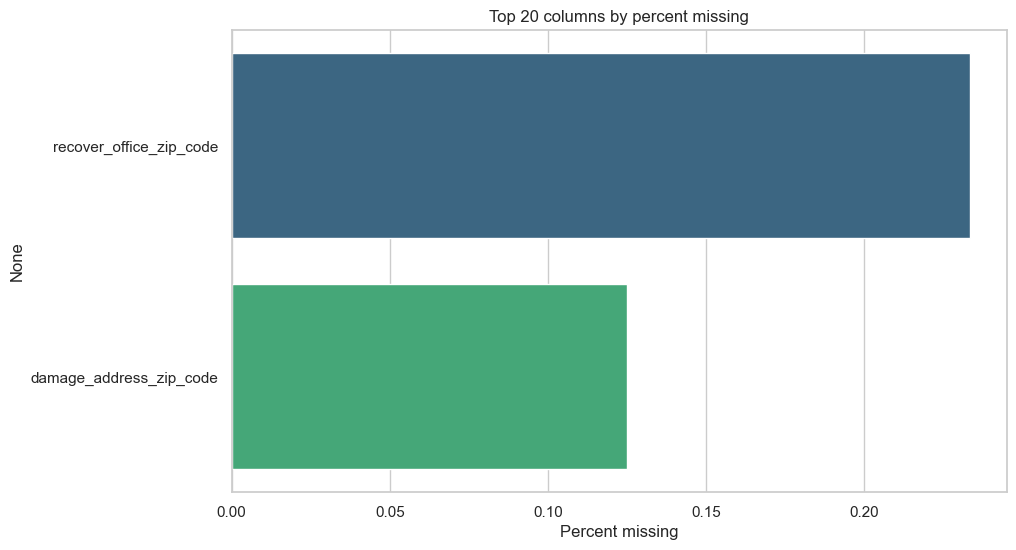


Recommendation: For columns with high missingness (>50%), consider removing or treating depending on domain importance. For low missingness, imputation (median/mode) is appropriate.


In [4]:
# Missing values summary
missing = data.isnull().sum()
missing_percent = (data.isnull().mean()*100)
missing_df = pd.concat([missing, missing_percent], axis=1)
missing_df.columns = ['missing_count', 'missing_percent']

# Show columns with any missing values
missing_show = missing_df[missing_df['missing_count']>0].sort_values('missing_percent', ascending=False)

print(f"Columns with missing values: {len(missing_show)}")
display(missing_show.head(50))

# Visualize top missing columns (if any)
if not missing_show.empty:
    top_missing = missing_show.head(20)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_missing['missing_percent'], y=top_missing.index, palette='viridis')
    plt.xlabel('Percent missing')
    plt.title('Top 20 columns by percent missing')
    plt.show()
else:
    print('No missing values found.')

# Recommendation placeholder
print('\nRecommendation: For columns with high missingness (>50%), consider removing or treating depending on domain importance. For low missingness, imputation (median/mode) is appropriate.')

## Data Type Analysis & Conversions

Inspect data types, attempt to convert date-like columns to datetime and string columns that look numeric to numeric types. Report any conversions and the effect on missingness.

In [5]:
# Show current data types
print(data.dtypes)

# Detect date-like columns by name and attempt conversion
date_like = [c for c in data.columns if 'date' in c.lower() or 'time' in c.lower()]
print('\nDate-like columns detected:', date_like)
for c in date_like:
    before_nulls = data[c].isnull().sum()
    data[c] = pd.to_datetime(data[c], errors='coerce')
    after_nulls = data[c].isnull().sum()
    print(f"Column {c}: nulls before={before_nulls}, after datetime conversion={after_nulls}")

# Attempt numeric conversion for object columns that look numeric
for c in data.select_dtypes(include=['object']).columns:
    # remove commas before conversion
    converted = pd.to_numeric(data[c].str.replace(',', ''), errors='coerce')
    converted_nonnull = converted.notnull().sum()
    if converted_nonnull >= len(data) * 0.8 and converted_nonnull > 0:  # threshold: 80% convertible
        data[c] = converted
        print(f"Converted column {c} to numeric (converted {converted_nonnull} values)")

# Show dtypes after conversion
print('\nData types after attempted conversions:')
print(data.dtypes)

insurance_company           object
recover_office_zip_code    float64
damage_address_zip_code    float64
office_distance             object
case_creation_year           int64
case_creation_month          int64
project_id                   int64
dtype: object

Date-like columns detected: []
Converted column office_distance to numeric (converted 60010 values)

Data types after attempted conversions:
insurance_company           object
recover_office_zip_code    float64
damage_address_zip_code    float64
office_distance              int64
case_creation_year           int64
case_creation_month          int64
project_id                   int64
dtype: object


## Univariate Analysis

Analyze distributions for numeric columns (histograms, boxplots, summary statistics) and frequency tables / bar charts for categorical columns. Limit the number of plots to keep the notebook readable; sample or summarize when there are many columns.

Numeric columns (6): ['recover_office_zip_code', 'damage_address_zip_code', 'office_distance', 'case_creation_year', 'case_creation_month', 'project_id']
Categorical columns (1): ['insurance_company']



,count,mean,std,min,25%,50%,75%,max
recover_office_zip_code,59870.0,4801.230399,2657.484058,182.0,2619.00,4636.0,7038.00,9912.0
damage_address_zip_code,59935.0,4790.843647,2662.837232,1.0,2609.00,4631.0,7046.00,9991.0
office_distance,60010.0,170.442626,321.210207,0.0,35.00,77.0,184.00,22583.0
case_creation_year,60010.0,2021.920580,1.551235,2015.0,2021.00,2022.0,2023.00,2025.0
case_creation_month,60010.0,6.237960,3.560266,1.0,3.00,6.0,9.00,12.0
project_id,60010.0,213605.403099,38538.920169,147474.0,180049.25,213787.5,247246.75,280589.0


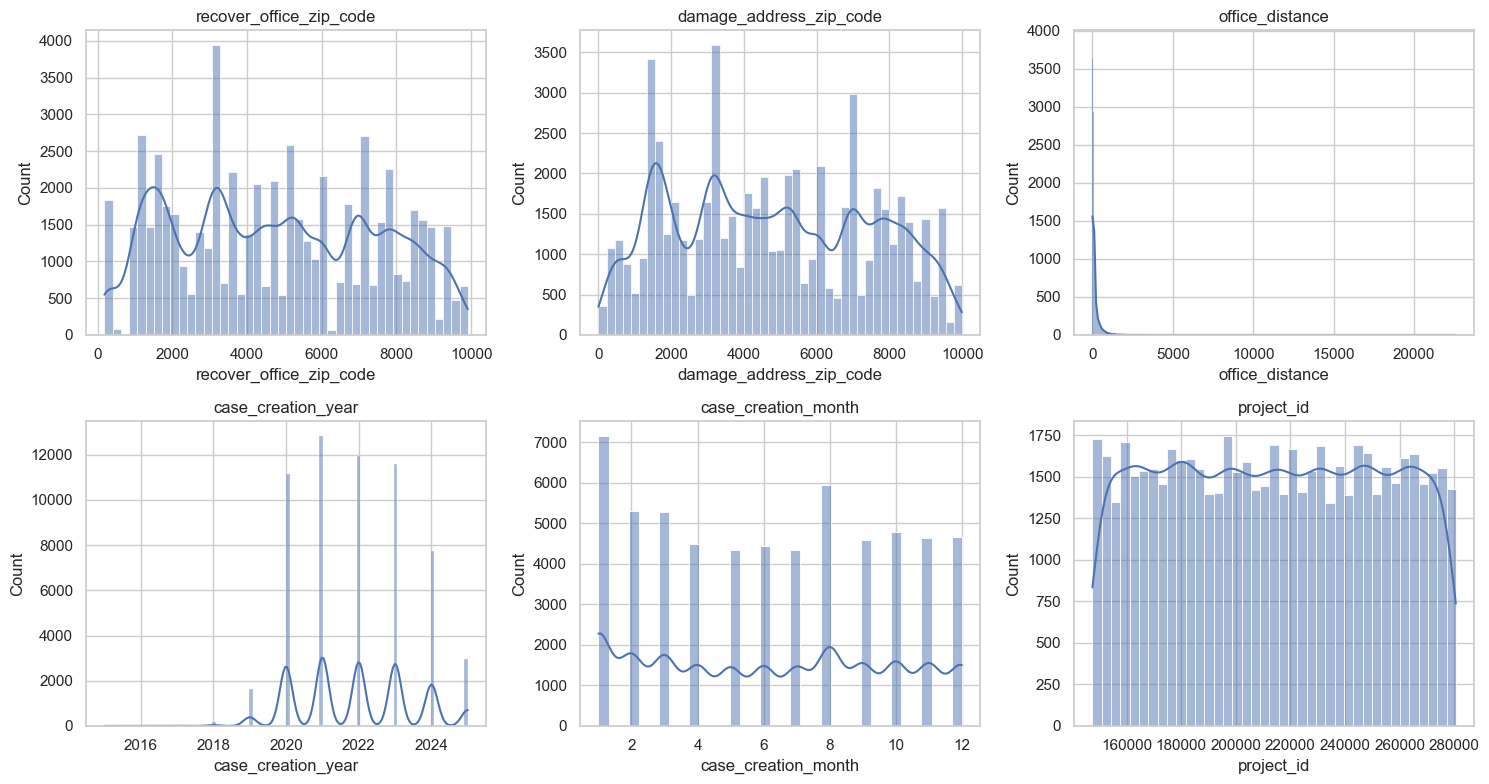

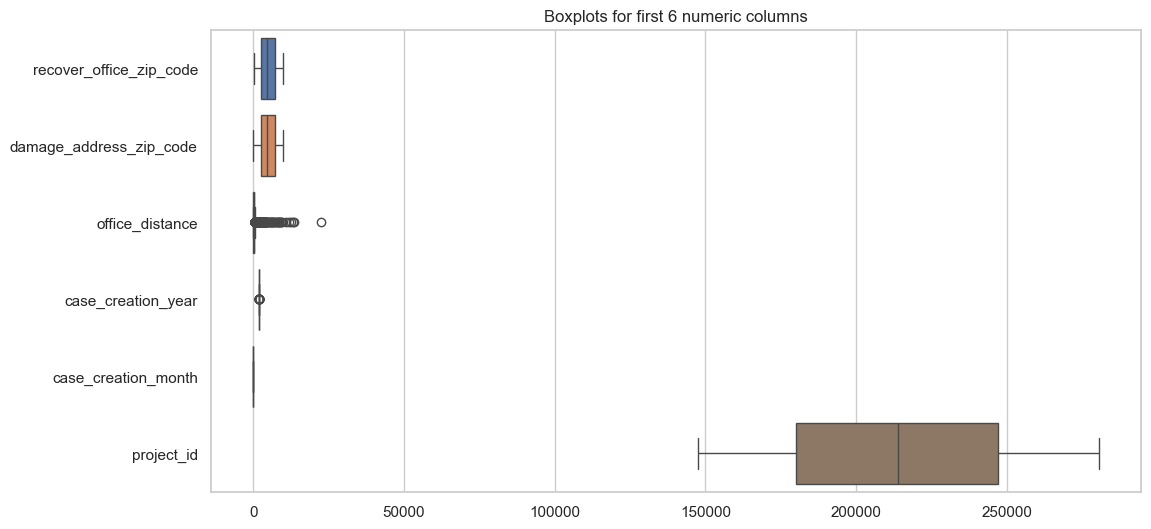


Top values for insurance_company (total unique: 14):


insurance_company
J    17958
C    15159
N     9810
K     5385
E     3883
D     3181
H     1988
G     1167
F      820
L      262
A      163
I      150
B       63
O       21
Name: count, dtype: int64

C:\Users\tobia\AppData\Local\Temp\ipykernel_47444\4111809740.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='crest')


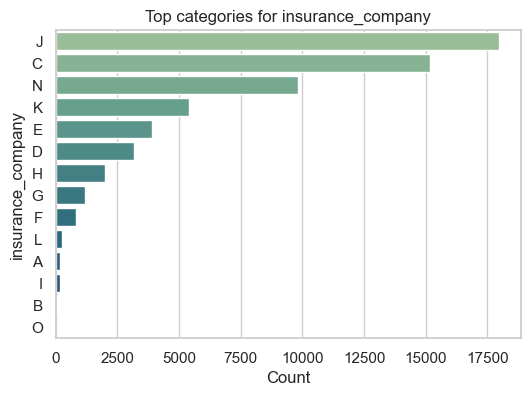

In [6]:
# Univariate analysis for numeric columns
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

# Numeric summary
if num_cols:
    display(data[num_cols].describe().T)
    # Plot histograms (limit to 12 columns to keep notebook readable)
    cols_to_plot = num_cols[:12]
    n = len(cols_to_plot)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(5*ncols, 4*nrows))
    for i, c in enumerate(cols_to_plot, 1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(data[c].dropna(), kde=True)
        plt.title(c)
    plt.tight_layout()
    plt.show()

    # Boxplots for numeric columns (first 6)
    cols_box = num_cols[:6]
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[cols_box], orient='h')
    plt.title('Boxplots for first 6 numeric columns')
    plt.show()

# Categorical summary
if cat_cols:
    for c in cat_cols[:10]:  # show up to 10 categorical cols
        vc = data[c].value_counts(dropna=False).head(20)
        print(f"\nTop values for {c} (total unique: {data[c].nunique(dropna=False)}):")
        display(vc)
        plt.figure(figsize=(6, min(4, len(vc)*0.25+1)))
        sns.barplot(x=vc.values, y=vc.index, palette='crest')
        plt.title(f'Top categories for {c}')
        plt.xlabel('Count')
        plt.show()